In [46]:
# PyTorch（CPU 版本）
!pip install torch torchvision --quiet


In [47]:
import os
import uuid
import shutil
import json
import copy
from datetime import datetime
import zipfile
import io
import requests
import random


In [48]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.pyplot import imshow
from tqdm import tqdm
from ipywidgets import IntProgress
import time 


In [49]:
import torch
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader,random_split
from torch.optim import lr_scheduler
from torchvision import transforms
import torch.nn as nn
torch.manual_seed(0)
from torchvision.datasets import ImageFolder


In [50]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

In [51]:
def plot_stuff(COST, ACC):
    """
    使用两个 y 轴在同一图中绘制训练代价（损失）和验证准确率。
    
    参数：
    COST（列表或数组）：每次迭代（或轮次）的总训练损失
    ACC（列表或数组）：每次迭代（或轮次）的验证准确率
    """
    
    # 创建新图和主轴 (ax1)
    fig, ax1 = plt.subplots()
    
    # 在左侧主轴 y 轴上绘制训练损失
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('迭代', color=color)            # x 轴标签
    ax1.set_ylabel('总损失', color=color)           # 左侧 y 轴标签
    ax1.tick_params(axis='y', labelcolor=color)         # 设置 y 轴刻度颜色

    # 创建共享同一 x 轴的次 y 轴 (ax2)
    ax2 = ax1.twinx()
    
    # 在右侧次 y 轴上绘制验证准确率
    color = 'tab:blue'
    ax2.set_ylabel('准确率', color=color)             # 右侧 y 轴标签
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # 调整布局以防止 y 轴标签被裁剪
    fig.tight_layout()
    
    # 显示组合图
    plt.show()


In [52]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("设备类型为", device)


设备类型为 cpu


In [53]:
import os
print("cwd current:", os.getcwd())

cwd current: /home/ahao/AI/projects/Python Guidance/day46-60


In [54]:
base_dir = os.path.dirname(os.path.abspath(__file__)) \
           if "__file__" in globals() else os.getcwd()
# ── 1. 自动解压 ──
zip_path = os.path.join(base_dir, "wine_quality.zip")
target_dir = os.path.join(base_dir, "wine_quality")

if not os.path.exists("wine_quality"):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("wine_quality")
    print("解压完成。")
else:
    print("文件夹已存在，跳过解压。")


文件夹已存在，跳过解压。


## RED wine 无监督

In [55]:
path = "wine_quality/winequality-red.csv"
df = pd.read_csv(path, sep=";")   # 关键：sep=";"
print(df.shape)                   # (1599, 12)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [56]:


FEATURES = df.columns[:11]  # 前 11 个特征：聚类唯一用到的输入
LABELS = df.columns[11]    # 后 11 列：真实类别，仅用于事后评估

X = df[FEATURES]
y = df[LABELS]  # 还原成单标签，只用于评估

# 不同值的数量
print(f"y nunique: {y.nunique()}")


y nunique: 6


In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### K-Means 聚类

真实类别有 6 种，所以先试试 k=6。K-Means 只知道“这是第 0~5 簇”，
簇编号和真实类别名没有任何对应关系，需要用交叉表人工对账。


In [58]:
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 交叉表：行 = 真实类别，列 = 聚类簇编号
pd.crosstab(y, clusters, rownames=["真实类别"], colnames=["簇编号"])


簇编号,0,1,2,3,4,5
真实类别,,,,,,
3,7,2,1,0,0,0
4,30,5,5,1,10,2
5,289,88,228,17,37,22
6,171,132,94,9,115,117
7,18,55,11,1,27,87
8,0,5,0,0,4,9


/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_l

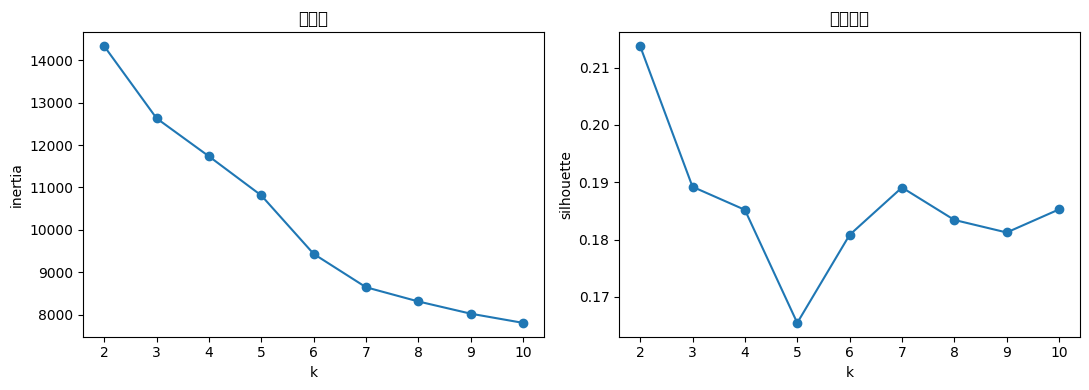

In [59]:
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, "o-")
axes[0].set(xlabel="k", ylabel="inertia", title="肘部法")
axes[1].plot(ks, silhouettes, "o-")
axes[1].set(xlabel="k", ylabel="silhouette", title="轮廓系数")
plt.tight_layout()
plt.show()


### 用真实标签评估聚类效果

虽然训练没用标签，但既然我们有，就可以量化“聚类结构”与“真实类别”
的一致程度（注意：这与分类的准确率不是同一个概念）：

- **ARI（调整兰德指数）**：取值 [-1, 1]，1 表示完全一致，0 为随机水平。
- **同质性（Homogeneity）**：同一簇里的样本是否属于同一真实类别。
- **完整性（Completeness）**：同一真实类别的样本是否被分到同一簇。


In [60]:
print(f"ARI         : {adjusted_rand_score(y, clusters):.3f}")
print(f"同质性 Homog: {homogeneity_score(y, clusters):.3f}")
print(f"完整性 Compl: {completeness_score(y, clusters):.3f}")


ARI         : 0.077
同质性 Homog: 0.124
完整性 Compl: 0.091


## PCA 降维可视化

把 11 维特征压缩到前两个主成分，在二维平面上观察：

- 左图按**真实类别**着色——检验有监督分类的难易度；
- 右图按**K-Means 簇**着色——检验无监督聚类是否还原了类似的结构。


/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from current font.
  plt.tight_l

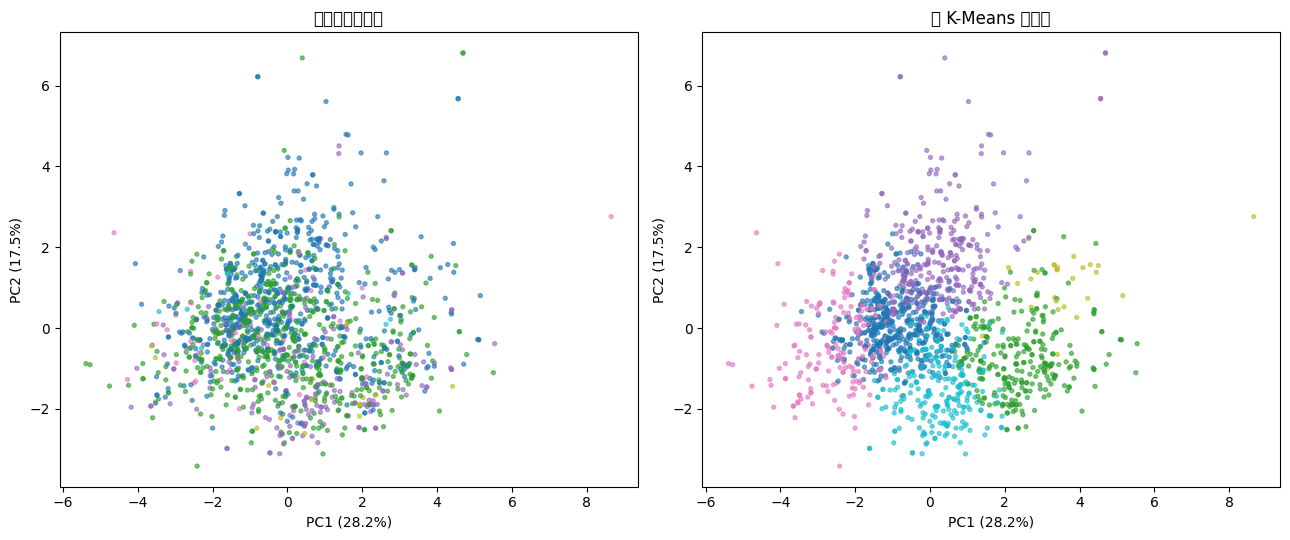

In [61]:
pca = PCA(n_components=2)   # 只保留前 2 个主成分
X_pca = pca.fit_transform(X_scaled)  # fit: 算协方差/做SVD，求出 v1、v2
                                    # transform: 完成投影，X_pca 是 1599×2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, coloring, title in [
    (axes[0], y, "按真实类别着色"),
    (axes[1], clusters, "按 K-Means 簇着色"),
]:
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(coloring)[0],
                         s=8, alpha=0.6, cmap="tab10")
    ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", title=title)
plt.tight_layout()
plt.show()


## White Wine

In [62]:
path = "wine_quality/winequality-white.csv"
df = pd.read_csv(path, sep=";")   # 关键：sep=";"
print(df.shape)                   # (1599, 12)
df.head()

(4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [63]:


FEATURES = df.columns[:11]  # 前 11 个特征：聚类唯一用到的输入
LABELS = df.columns[11]    # 后 11 列：真实类别，仅用于事后评估

X = df[FEATURES]
y = df[LABELS]  # 还原成单标签，只用于评估

# 不同值的数量
print(f"y nunique: {y.nunique()}")


y nunique: 7


In [64]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [65]:
kmeans = KMeans(n_clusters=7, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 交叉表：行 = 真实类别，列 = 聚类簇编号
pd.crosstab(y, clusters, rownames=["真实类别"], colnames=["簇编号"])


簇编号,0,1,2,3,4,5,6
真实类别,,,,,,,
3,2,7,0,2,2,6,1
4,46,17,9,20,19,48,4
5,273,415,64,50,325,281,49
6,457,372,251,324,347,399,48
7,126,33,156,315,102,146,2
8,21,6,30,73,18,25,2
9,0,0,0,4,0,1,0


/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 32920 (\N{CJK UNIFIED IDEOGRAPH-8098}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 24275 (\N{CJK UNIFIED IDEOGRAPH-5ED3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2835925689.py:15: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_l

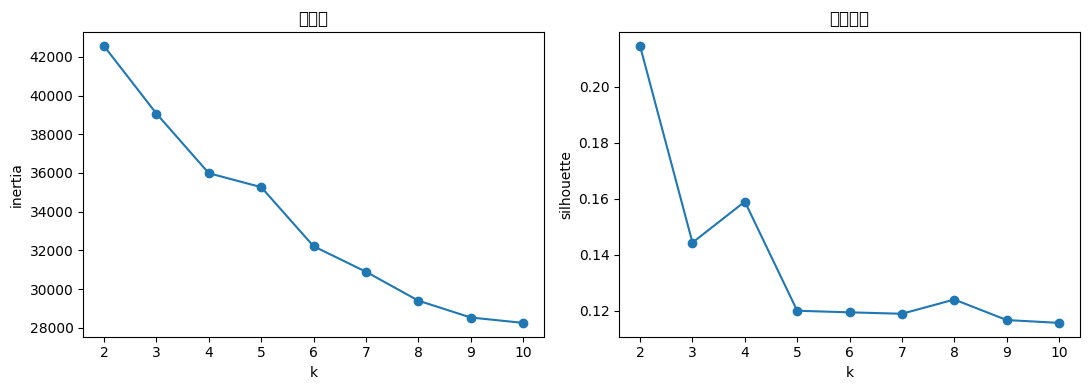

In [66]:
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, "o-")
axes[0].set(xlabel="k", ylabel="inertia", title="肘部法")
axes[1].plot(ks, silhouettes, "o-")
axes[1].set(xlabel="k", ylabel="silhouette", title="轮廓系数")
plt.tight_layout()
plt.show()


In [67]:
print(f"ARI         : {adjusted_rand_score(y, clusters):.3f}")
print(f"同质性 Homog: {homogeneity_score(y, clusters):.3f}")
print(f"完整性 Compl: {completeness_score(y, clusters):.3f}")


ARI         : 0.030
同质性 Homog: 0.075
完整性 Compl: 0.052


/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3176/2617183001.py:13: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from current font.
  plt.tight_l

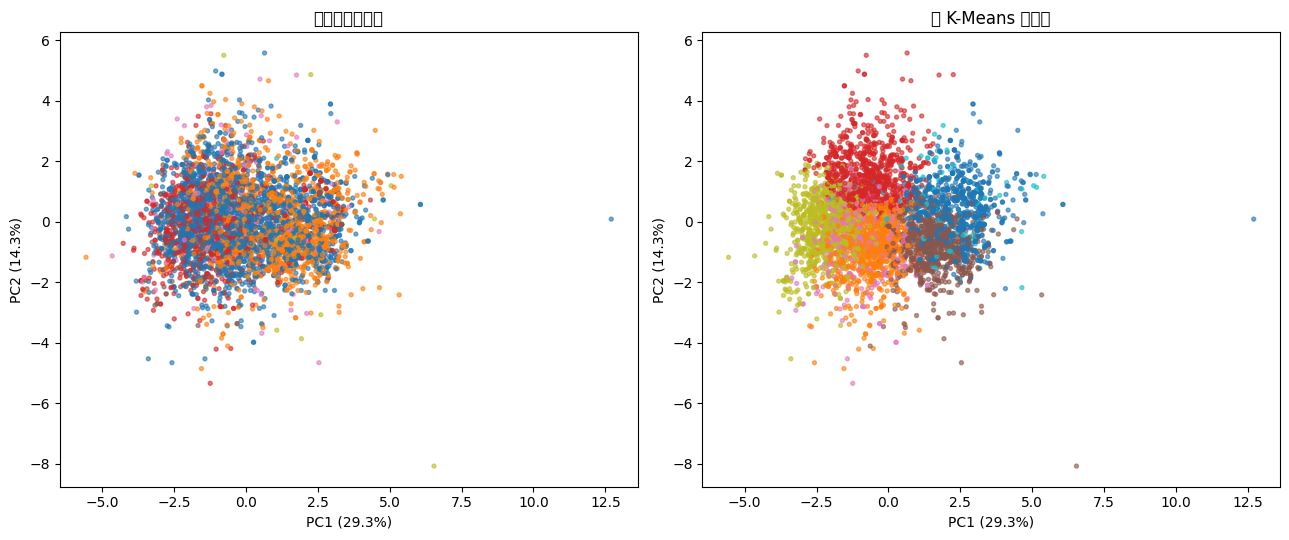

In [68]:
pca = PCA(n_components=2)   # 只保留前 2 个主成分
X_pca = pca.fit_transform(X_scaled)  # fit: 算协方差/做SVD，求出 v1、v2
                                    # transform: 完成投影，X_pca 是 1599×2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, coloring, title in [
    (axes[0], y, "按真实类别着色"),
    (axes[1], clusters, "按 K-Means 簇着色"),
]:
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(coloring)[0],
                         s=8, alpha=0.6, cmap="tab10")
    ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", title=title)
plt.tight_layout()
plt.show()
